<a href="https://colab.research.google.com/github/vignesh-codes/ECE9063-Assignment-1/blob/main/arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv')
df = df.iloc[:25000]
# Convert the 'date' column to datetime format
# df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['date'] = pd.to_datetime(df['date'])
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Extract useful features from the date
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Add lag features (e.g., sales from the previous day, week, and 12 months ago)
df['lag_1'] = df['sales'].shift(1)  # Previous day's sales
df['lag_7'] = df['sales'].shift(7)  # Previous week's sales
df['lag_365'] = df['sales'].shift(365)  # Previous year's sales (seasonality)

# Add rolling mean (7-day and 30-day rolling averages)
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].rolling(window=30).mean()

# Drop any rows with missing values (due to lag and rolling operations)
df = df.dropna()
# sort the data by timestamp
df = df.sort_values(by='date')
df.head(10)

,date,store,item,sales,day,month,year,lag_1,lag_7,lag_365,rolling_mean_7,rolling_mean_30
14608,2013-01-01,9,1,11,1,1,2013,26.0,17.0,32.0,23.000000,22.666667
10956,2013-01-01,7,1,7,1,1,2013,19.0,10.0,18.0,12.571429,13.366667
16434,2013-01-01,10,1,14,1,1,2013,19.0,14.0,16.0,18.857143,19.133333
21912,2013-01-01,3,2,43,1,1,2013,79.0,57.0,65.0,65.714286,62.700000
9130,2013-01-01,6,1,20,1,1,2013,24.0,17.0,11.0,17.285714,15.066667
7304,2013-01-01,5,1,11,1,1,2013,23.0,16.0,16.0,20.285714,20.033333
18260,2013-01-01,1,2,33,1,1,2013,27.0,10.0,25.0,22.285714,20.500000
3652,2013-01-01,3,1,19,1,1,2013,31.0,18.0,33.0,22.428571,22.133333
1826,2013-01-01,2,1,12,1,1,2013,23.0,13.0,19.0,18.000000,17.000000
20086,2013-01-01,2,2,41,1,1,2013,67.0,37.0,40.0,51.714286,46.533333


In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 2. Fit the SARIMAX Model (ARIMA with exogenous variables)
# Define the order of the model (p, d, q)
p = 1
d = 0  # No differencing for ARMA
q = 1

# Set exogenous variables
exogenous_vars = df[['month', 'lag_1', 'lag_7', 'lag_365', 'rolling_mean_7', 'rolling_mean_30']]

# Fit the SARIMAX model
model = SARIMAX(df['sales'], order=(p, d, q), exog=exogenous_vars)
model_fit = model.fit()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [8]:
# 3. Make Predictions
forecast_steps = 2500
# Prepare exogenous variable for forecasting
forecast_exog = exogenous_vars.iloc[-forecast_steps:].values
forecast = model_fit.forecast(steps=forecast_steps, exog=forecast_exog)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
# 4. Evaluate the Model
# Here we can compare the predicted values with the last known sales data
actual_sales = df['sales'].tail(forecast_steps)

# Calculate Mean Absolute Error (MAE) for the last forecasted values
mae = mean_absolute_error(actual_sales, forecast)
print(f'Mean Absolute Error (MAE): {mae}')


Mean Absolute Error (MAE): 5.395458724572172


In [10]:
print(forecast.info())
forecast.head()

<class 'pandas.core.series.Series'>
RangeIndex: 2500 entries, 24635 to 27134
Series name: predicted_mean
Non-Null Count  Dtype  
--------------  -----  
2500 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB
None


,predicted_mean
24635,30.654515
24636,40.142639
24637,26.244582
24638,74.085902
24639,109.385675


In [11]:
df.info()
df.tail(10)

<class 'pandas.core.frame.DataFrame'>
Index: 24635 entries, 14608 to 14607
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             24635 non-null  datetime64[ns]
 1   store            24635 non-null  int64         
 2   item             24635 non-null  int64         
 3   sales            24635 non-null  int64         
 4   day              24635 non-null  int32         
 5   month            24635 non-null  int32         
 6   year             24635 non-null  int32         
 7   lag_1            24635 non-null  float64       
 8   lag_7            24635 non-null  float64       
 9   lag_365          24635 non-null  float64       
 10  rolling_mean_7   24635 non-null  float64       
 11  rolling_mean_30  24635 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int32(3), int64(3)
memory usage: 2.2 MB


,date,store,item,sales,day,month,year,lag_1,lag_7,lag_365,rolling_mean_7,rolling_mean_30
5477,2017-12-31,3,1,19,31,12,2017,31.0,27.0,26.0,19.000000,23.000000
9129,2017-12-31,5,1,24,31,12,2017,19.0,14.0,12.0,16.857143,15.066667
16433,2017-12-31,9,1,19,31,12,2017,31.0,33.0,26.0,18.857143,19.166667
20085,2017-12-31,1,2,67,31,12,2017,56.0,47.0,47.0,51.142857,47.300000
10955,2017-12-31,6,1,19,31,12,2017,10.0,21.0,15.0,13.000000,13.733333
12781,2017-12-31,7,1,16,31,12,2017,17.0,13.0,12.0,14.142857,12.966667
7303,2017-12-31,4,1,23,31,12,2017,21.0,25.0,15.0,21.000000,20.633333
21911,2017-12-31,2,2,79,31,12,2017,74.0,71.0,63.0,67.714286,63.433333
23737,2017-12-31,3,2,68,31,12,2017,68.0,60.0,64.0,60.000000,57.400000
14607,2017-12-31,8,1,26,31,12,2017,30.0,22.0,22.0,23.857143,23.266667


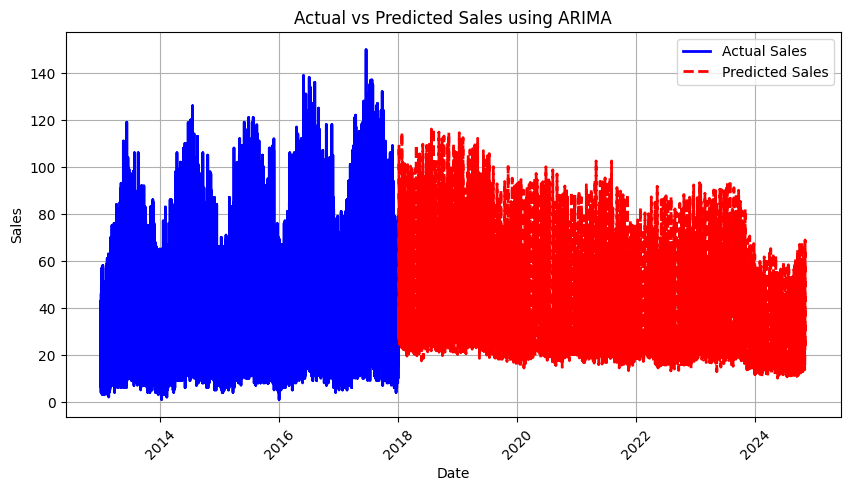

In [12]:
# 6. Visualization

# Get the last date from the actual sales DataFrame
last_date = df['date'].iloc[-1]  # This should give the last datetime entry

# Create a date range for the forecast index starting from the next day
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(forecast), freq='D')

# Plot the actual vs predicted sales
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['sales'], label='Actual Sales', color='blue', linewidth=2)  # Actual sales data
plt.plot(forecast_index, forecast.values, label='Predicted Sales', color='red', linestyle='--', linewidth=2)  # Predicted sales

plt.title('Actual vs Predicted Sales using ARIMA')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.show()
